In [ ]:
# Panoptic Mask2Former‑ResNet50 on WaRP‑S

# 1: Imports, config, device, seeds
import sys, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision import models

from collections import defaultdict
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

# -------- Config --------
IMG_SIZE      = 384
BATCH_SIZE    = 2
NUM_WORKERS   = 0
EPOCHS        = 80
LR            = 1e-4
WEIGHT_DECAY  = 1e-5
NUM_QUERIES   = 100
THING_CLASSES = None  # if None, treat all non-background as "things"

# -------- Root detection --------
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Project root: c:\repo\Waste-Classification
Device: cuda


In [ ]:
# [markdown]
# 2: Paths, labelmap, class mapping


WARP_S_ROOT   = root / "Dataset/raw/WaRP-S"
if not WARP_S_ROOT.exists():
    WARP_S_ROOT = root / "Dataset/raw/Warp-S"

IMAGESETS_TXT = WARP_S_ROOT / "ImageSets/Segmentation/default.txt"
IMAGES_DIR    = WARP_S_ROOT / "JPEGImages"
MASKS_DIR     = WARP_S_ROOT / "SegmentationClass"
LABELMAP_FILE = WARP_S_ROOT / "labelmap.txt"

print("WaRP‑S root :", WARP_S_ROOT)
print("Images dir  :", IMAGES_DIR)
print("Masks dir   :", MASKS_DIR)
print("ImageSet    :", IMAGESETS_TXT)
print("Labelmap    :", LABELMAP_FILE)

class_names = []
rgb_to_id = {}

with open(LABELMAP_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        name, rest = line.split(":")[0], line.split(":")[1]
        rgb_str = rest.split("::")[0]
        r, g, b = map(int, rgb_str.split(","))
        class_names.append(name)
        rgb_to_id[(r, g, b)] = len(class_names) - 1

NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} classes:")
for i, n in enumerate(class_names):
    print(f"{i:2d}: {n}")

BACKGROUND_CLASS = 0  # assume first is background if labelmap is ordered that way

WaRP‑S root : c:\repo\Waste-Classification\Dataset\raw\WaRP-S
Images dir  : c:\repo\Waste-Classification\Dataset\raw\WaRP-S\JPEGImages
Masks dir   : c:\repo\Waste-Classification\Dataset\raw\WaRP-S\SegmentationClass
ImageSet    : c:\repo\Waste-Classification\Dataset\raw\WaRP-S\ImageSets\Segmentation\default.txt
Labelmap    : c:\repo\Waste-Classification\Dataset\raw\WaRP-S\labelmap.txt
Found 29 classes:
 0: background
 1: bottle-blue
 2: bottle-blue-full
 3: bottle-blue5l
 4: bottle-blue5l-full
 5: bottle-dark
 6: bottle-dark-full
 7: bottle-green
 8: bottle-green-full
 9: bottle-milk
10: bottle-milk-full
11: bottle-multicolor
12: bottle-multicolorv-full
13: bottle-oil
14: bottle-oil-full
15: bottle-transp
16: bottle-transp-full
17: bottle-yogurt
18: canister
19: cans
20: detergent-box
21: detergent-color
22: detergent-transparent
23: detergent-white
24: glass-dark
25: glass-green
26: glass-transp
27: juice-cardboard
28: milk-cardboard


In [ ]:
# [markdown]
# 3: Load IDs

with open(IMAGESETS_TXT, "r") as f:
    all_ids = [line.strip() for line in f if line.strip()]

valid_ids = []
for img_id in all_ids:
    if (MASKS_DIR / f"{img_id}.png").exists():
        valid_ids.append(img_id)

print("Total valid IDs:", len(valid_ids))

Total valid IDs: 112


In [ ]:
# [markdown]
# 4: Augmentations


class WarpSAugment:
    def __init__(self, size):
        self.size = size

    def __call__(self, img, mask_ids):
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask_ids = np.fliplr(mask_ids)

        if random.random() < 0.5:
            angle = random.uniform(-8, 8)
            img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
            mask_pil = Image.fromarray(mask_ids.astype(np.uint8), mode="L")
            mask_pil = TF.rotate(mask_pil, angle, interpolation=TF.InterpolationMode.NEAREST)
            mask_ids = np.array(mask_pil)

        if random.random() < 0.5:
            img = TF.adjust_brightness(img, 0.9 + 0.2 * random.random())
            img = TF.adjust_contrast(img, 0.9 + 0.2 * random.random())

        img = TF.resize(img, (self.size, self.size))
        mask_pil = Image.fromarray(mask_ids.astype(np.uint8), mode="L")
        mask_pil = TF.resize(mask_pil, (self.size, self.size),
                             interpolation=TF.InterpolationMode.NEAREST)
        mask_ids = np.array(mask_pil)

        img = TF.to_tensor(img)
        img = TF.normalize(
            img,
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

        mask_ids = torch.as_tensor(mask_ids, dtype=torch.long)
        return img, mask_ids

In [ ]:
# 5: Palette‑aware mask loading + dataset

def rgb_to_class(mask_np, rgb_to_id):
    h, w, _ = mask_np.shape
    flat = mask_np.reshape(-1, 3)

    label_colors = np.array(list(rgb_to_id.keys()))
    label_ids    = np.array(list(rgb_to_id.values()))

    dists = np.linalg.norm(flat[:, None, :] - label_colors[None, :, :], axis=2)
    nearest = np.argmin(dists, axis=1)
    out = label_ids[nearest].reshape(h, w).astype(np.uint8)
    return out


class WarpSSegmentationDataset(Dataset):
    def __init__(self, ids, images_dir, masks_dir, augment, rgb_to_id):
        self.ids = ids
        self.images_dir = Path(images_dir)
        self.masks_dir  = Path(masks_dir)
        self.augment = augment
        self.rgb_to_id = rgb_to_id

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        img  = Image.open(self.images_dir / f"{img_id}.jpg").convert("RGB")
        mask = Image.open(self.masks_dir  / f"{img_id}.png")

        if mask.mode == "P":
            mask_ids = np.array(mask, dtype=np.uint8)
        else:
            mask_np = np.array(mask.convert("RGB"))
            mask_ids = rgb_to_class(mask_np, self.rgb_to_id)

        if self.augment is not None:
            img, mask_ids = self.augment(img, mask_ids)
        else:
            img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
            mask_pil = Image.fromarray(mask_ids.astype(np.uint8), mode="L")
            mask_pil = TF.resize(mask_pil, (IMG_SIZE, IMG_SIZE),
                                 interpolation=TF.InterpolationMode.NEAREST)
            mask_ids = np.array(mask_pil)

            img = TF.to_tensor(img)
            img = TF.normalize(
                img,
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            )
            mask_ids = torch.as_tensor(mask_ids, dtype=torch.long)

        return img, mask_ids

In [ ]:
# 6: Class‑aware stratified split

image_classes = defaultdict(set)

for img_id in valid_ids:
    mask = Image.open(MASKS_DIR / f"{img_id}.png")
    if mask.mode == "P":
        mask_ids = np.array(mask)
    else:
        mask_np = np.array(mask.convert("RGB"))
        mask_ids = rgb_to_class(mask_np, rgb_to_id)

    for u in np.unique(mask_ids):
        image_classes[img_id].add(int(u))

class_to_images = defaultdict(list)
for img_id, classes in image_classes.items():
    for c in classes:
        class_to_images[c].append(img_id)

train_ids = set()
val_ids   = set()

random.seed(42)

for c, imgs in class_to_images.items():
    if len(imgs) == 1:
        train_ids.add(imgs[0])
    else:
        val_choice = random.choice(imgs)
        val_ids.add(val_choice)
        for img in imgs:
            if img != val_choice:
                train_ids.add(img)

train_ids = sorted(list(train_ids))
val_ids   = sorted(list(val_ids))

print("Train:", len(train_ids))
print("Val  :", len(val_ids))

Train: 112
Val  : 28


In [ ]:
# 7: DataLoaders

train_ds = WarpSSegmentationDataset(
    ids=train_ids,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    augment=WarpSAugment(size=IMG_SIZE),
    rgb_to_id=rgb_to_id,
)

val_ds = WarpSSegmentationDataset(
    ids=val_ids,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    augment=None,
    rgb_to_id=rgb_to_id,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 56
Val batches  : 14


In [ ]:
# 8: ResNet50 backbone

class ResNet50Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1  # 1/4
        self.layer2 = backbone.layer2  # 1/8
        self.layer3 = backbone.layer3  # 1/16
        self.layer4 = backbone.layer4  # 1/32

    def forward(self, x):
        x = self.stem(x)
        c1 = self.layer1(x)
        c2 = self.layer2(c1)
        c3 = self.layer3(c2)
        c4 = self.layer4(c3)
        return c1, c2, c3, c4

In [ ]:
# 9: Pixel decoder + positional encoding

class PixelDecoder(nn.Module):
    def __init__(self, in_channels_list, embed_dim=256):
        super().__init__()
        self.proj = nn.ModuleList()
        for in_ch in in_channels_list:
            self.proj.append(
                nn.Conv2d(in_ch, embed_dim, kernel_size=1, bias=False)
            )
        self.ln = nn.GroupNorm(32, embed_dim)

    def forward(self, features):
        c1, c2, c3, c4 = features
        B, _, H, W = c1.shape

        outs = []
        for feat, proj in zip([c1, c2, c3, c4], self.proj):
            x = proj(feat)
            x = F.interpolate(x, size=(H, W), mode="bilinear", align_corners=False)
            outs.append(x)

        x = sum(outs) / len(outs)
        x = self.ln(x)
        return x  # [B, C, H, W]


class PositionalEncoding2D(nn.Module):
    def __init__(self, num_feats=128):
        super().__init__()
        self.num_feats = num_feats

    def forward(self, x):
        B, C, H, W = x.shape
        device = x.device

        y_embed = torch.linspace(0, 1, H, device=device).unsqueeze(1).repeat(1, W)
        x_embed = torch.linspace(0, 1, W, device=device).unsqueeze(0).repeat(H, 1)

        dim_t = torch.arange(self.num_feats, device=device, dtype=torch.float32)
        dim_t = 10000 ** (2 * (dim_t // 2) / self.num_feats)

        pos_x = x_embed[..., None] / dim_t
        pos_y = y_embed[..., None] / dim_t

        pos_x = torch.stack((pos_x[..., 0::2].sin(), pos_x[..., 1::2].cos()), dim=-1).flatten(-2)
        pos_y = torch.stack((pos_y[..., 0::2].sin(), pos_y[..., 1::2].cos()), dim=-1).flatten(-2)

        pos = torch.cat((pos_y, pos_x), dim=-1)  # [H, W, 2*num_feats]
        pos = pos.permute(2, 0, 1).unsqueeze(0).repeat(B, 1, 1, 1)
        return pos[:, :x.shape[1], :, :]

In [ ]:
# 10: Mask2Former head (queries, transformer decoder)

class Mask2FormerHead(nn.Module):
    def __init__(self, embed_dim, num_classes, num_queries=100, num_heads=8, num_layers=6):
        super().__init__()
        self.num_queries = num_queries
        self.num_classes = num_classes
        self.embed_dim = embed_dim

        self.query_embed = nn.Embedding(num_queries, embed_dim)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=2048,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=num_layers,
        )

        self.class_embed = nn.Linear(embed_dim, num_classes + 1)  # +1 for "no object"
        self.mask_embed  = nn.Linear(embed_dim, embed_dim)

    def forward(self, pixel_features, pos_embed):
        B, C, H, W = pixel_features.shape

        src = pixel_features.flatten(2).permute(0, 2, 1)      # [B, HW, C]
        pos = pos_embed.flatten(2).permute(0, 2, 1)           # [B, HW, C]

        queries = self.query_embed.weight.unsqueeze(0).repeat(B, 1, 1)  # [B, Q, C]

        tgt = queries
        memory = src + pos

        hs = self.transformer_decoder(tgt=tgt, memory=memory)  # [B, Q, C]

        class_logits = self.class_embed(hs)   # [B, Q, num_classes+1]
        mask_embed   = self.mask_embed(hs)    # [B, Q, C]

        pixel_embed = pixel_features          # [B, C, H, W]
        masks = torch.einsum("bqc,bchw->bqhw", mask_embed, pixel_embed)

        return class_logits, masks

In [ ]:
# 11: Full Mask2Former‑ResNet50 model

class Mask2FormerResNet50(nn.Module):
    def __init__(self, num_classes, num_queries=100, embed_dim=256):
        super().__init__()
        self.backbone = ResNet50Backbone()
        self.pixel_decoder = PixelDecoder(
            in_channels_list=[256, 512, 1024, 2048],
            embed_dim=embed_dim,
        )
        self.pos_encoding = PositionalEncoding2D(num_feats=embed_dim // 2)
        self.head = Mask2FormerHead(
            embed_dim=embed_dim,
            num_classes=num_classes,
            num_queries=num_queries,
        )

    def forward(self, x):
        c1, c2, c3, c4 = self.backbone(x)
        pixel_feats = self.pixel_decoder((c1, c2, c3, c4))  # [B, C, H/4, W/4]
        pos = self.pos_encoding(pixel_feats)
        class_logits, masks = self.head(pixel_feats, pos)
        return class_logits, masks  # masks at 1/4 resolution


model = Mask2FormerResNet50(
    num_classes=NUM_CLASSES,
    num_queries=NUM_QUERIES,
    embed_dim=256,
).to(DEVICE)

print("Model ready.")

Model ready.


In [ ]:
# 12: Hungarian matching + losses

def dice_loss(inputs, targets, eps=1e-6):
    inputs = inputs.sigmoid()
    inputs = inputs.flatten(1)
    targets = targets.flatten(1)
    intersection = (inputs * targets).sum(1)
    union = inputs.sum(1) + targets.sum(1)
    loss = 1 - (2 * intersection + eps) / (union + eps)
    return loss.mean()


def sigmoid_ce_loss(inputs, targets):
    return F.binary_cross_entropy_with_logits(inputs, targets, reduction="mean")


def get_targets_for_image(mask_ids, num_classes):
    """
    From semantic mask [H, W] → list of instance masks + class labels.
    Here: treat each class (except background) as one instance.
    """
    h, w = mask_ids.shape
    instances = []
    labels = []

    unique_classes = np.unique(mask_ids)
    for c in unique_classes:
        if c == BACKGROUND_CLASS:
            continue
        inst_mask = (mask_ids == c).astype(np.float32)
        if inst_mask.sum() < 10:  # tiny region, skip
            continue
        instances.append(inst_mask)
        labels.append(int(c))

    if len(instances) == 0:
        # no foreground: one dummy background instance
        instances = [np.zeros((h, w), dtype=np.float32)]
        labels = [BACKGROUND_CLASS]

    instances = np.stack(instances, axis=0)  # [N, H, W]
    labels = np.array(labels, dtype=np.int64)
    return instances, labels

def hungarian_match(pred_logits, pred_masks, gt_labels, gt_masks):
    """
    pred_logits: [Q, C+1]
    pred_masks:  [Q, H, W]
    gt_labels:   [N]
    gt_masks:    [N, H, W]
    """
    Q, H, W = pred_masks.shape
    N = gt_masks.shape[0]

    if N == 0:
        return torch.empty(0, dtype=torch.long), torch.empty(0, dtype=torch.long)

    with torch.no_grad():
        out_prob = pred_logits.softmax(-1)  # [Q, C+1]
        out_masks = pred_masks.sigmoid()    # [Q, H, W]

        gt_masks_t = torch.as_tensor(gt_masks, device=pred_masks.device)  # [N, H, W]
        gt_labels_t = torch.as_tensor(gt_labels, device=pred_logits.device)

        # classification cost
        cost_class = -out_prob[:, gt_labels_t]  # [Q, N]

        # mask cost (BCE)
        out_masks_flat = out_masks.flatten(1)          # [Q, HW]
        gt_masks_flat  = gt_masks_t.flatten(1)         # [N, HW]
        cost_mask = F.binary_cross_entropy(
            out_masks_flat.unsqueeze(1).repeat(1, N, 1),
            gt_masks_flat.unsqueeze(0).repeat(Q, 1, 1),
            reduction="none",
        ).mean(-1)  # [Q, N]

        # dice cost
        inter = (out_masks_flat.unsqueeze(1) * gt_masks_flat.unsqueeze(0)).sum(-1)
        union = out_masks_flat.unsqueeze(1).sum(-1) + gt_masks_flat.unsqueeze(0).sum(-1)
        cost_dice = 1 - (2 * inter + 1e-6) / (union + 1e-6)  # [Q, N]

        C = cost_class + cost_mask + cost_dice
        C = C.cpu().numpy()
        row_ind, col_ind = linear_sum_assignment(C)

    return torch.as_tensor(row_ind, dtype=torch.long), torch.as_tensor(col_ind, dtype=torch.long)

def loss_for_batch(class_logits, masks, targets, num_classes):
    """
    class_logits: [B, Q, C+1]
    masks:        [B, Q, H, W]
    targets:      [B, H_full, W_full] (semantic)
    """
    B, Q, H4, W4 = masks.shape
    total_loss_ce = 0.0
    total_loss_dice = 0.0
    total_loss_bce = 0.0

    for b in range(B):
        tgt_sem = targets[b].cpu().numpy()
        gt_masks_np, gt_labels_np = get_targets_for_image(tgt_sem, num_classes)

        gt_masks_t = torch.as_tensor(gt_masks_np, device=masks.device)  # [N, H4?, W4?]
        gt_labels_t = torch.as_tensor(gt_labels_np, device=class_logits.device)

        # downsample GT masks to H4, W4
        gt_masks_t = F.interpolate(
            gt_masks_t.unsqueeze(1),
            size=(H4, W4),
            mode="nearest",
        ).squeeze(1)

        pred_logits_b = class_logits[b]  # [Q, C+1]
        pred_masks_b  = masks[b]        # [Q, H4, W4]

        idx_q, idx_gt = hungarian_match(pred_logits_b, pred_masks_b, gt_labels_t, gt_masks_t)

        if idx_q.numel() == 0:
            continue

        matched_logits = pred_logits_b[idx_q]  # [M, C+1]
        matched_masks  = pred_masks_b[idx_q]   # [M, H4, W4]
        matched_labels = gt_labels_t[idx_gt]   # [M]
        matched_gtmasks = gt_masks_t[idx_gt]   # [M, H4, W4]

        # classification loss
        loss_ce = F.cross_entropy(matched_logits, matched_labels, reduction="mean")

        # mask losses
        loss_dice = dice_loss(matched_masks, matched_gtmasks)
        loss_bce  = sigmoid_ce_loss(matched_masks, matched_gtmasks)

        total_loss_ce   += loss_ce
        total_loss_dice += loss_dice
        total_loss_bce  += loss_bce

    num = max(B, 1)
    return (total_loss_ce / num,
            total_loss_dice / num,
            total_loss_bce / num)

In [ ]:
# 13: Semantic + panoptic outputs + PQ

def semantic_from_queries(class_logits, masks, num_classes):
    """
    Aggregate per-query masks into per-class logits, then argmax.
    """
    B, Q, H, W = masks.shape
    probs = class_logits.softmax(-1)  # [B, Q, C+1]
    class_probs = probs[..., :num_classes]  # ignore "no object"

    masks_sig = masks.sigmoid()  # [B, Q, H, W]

    sem_logits = torch.zeros(B, num_classes, H, W, device=masks.device)
    for c in range(num_classes):
        cls_scores = class_probs[..., c]  # [B, Q]
        cls_scores = cls_scores.unsqueeze(-1).unsqueeze(-1)  # [B, Q, 1, 1]
        sem_logits[:, c] = (cls_scores * masks_sig).sum(dim=1)

    sem_pred = sem_logits.argmax(1)  # [B, H, W]
    return sem_pred, sem_logits


def panoptic_from_queries(class_logits, masks, score_thresh=0.5, mask_thresh=0.5):
    """
    Build panoptic map: each instance gets a unique ID.
    """
    B, Q, H, W = masks.shape
    probs = class_logits.softmax(-1)  # [B, Q, C+1]
    scores, labels = probs.max(-1)    # [B, Q]

    panoptic_maps = []
    instance_info = []

    for b in range(B):
        pan_map = torch.zeros(H, W, dtype=torch.int32, device=masks.device)
        insts = []
        inst_id = 1

        for q in range(Q):
            cls = labels[b, q].item()
            if cls == NUM_CLASSES:  # "no object"
                continue
            score = scores[b, q].item()
            if score < score_thresh:
                continue

            mask_q = masks[b, q].sigmoid()
            mask_bin = (mask_q > mask_thresh).float()

            if mask_bin.sum() < 20:
                continue

            overlap = (pan_map > 0) & (mask_bin > 0)
            if overlap.float().sum() / mask_bin.sum() > 0.7:
                continue

            pan_map[mask_bin > 0] = inst_id
            insts.append((inst_id, cls, score))
            inst_id += 1

        panoptic_maps.append(pan_map)
        instance_info.append(insts)

    return panoptic_maps, instance_info


def pq_metric(panoptic_pred, panoptic_gt, class_map_pred, class_map_gt):
    """
    Approximate PQ: treat each instance ID in pred/gt, use IoU threshold 0.5.
    class_map_pred/gt: semantic class per pixel.
    """
    pred_ids = panoptic_pred.unique()
    gt_ids   = panoptic_gt.unique()

    pred_ids = pred_ids[pred_ids > 0]
    gt_ids   = gt_ids[gt_ids > 0]

    tp = 0
    fp = 0
    fn = 0
    sum_iou = 0.0

    for pid in pred_ids:
        mask_p = (panoptic_pred == pid)
        cls_p = class_map_pred[mask_p].mode()[0].item() if mask_p.sum() > 0 else BACKGROUND_CLASS

        best_iou = 0.0
        best_gid = None
        for gid in gt_ids:
            mask_g = (panoptic_gt == gid)
            cls_g = class_map_gt[mask_g].mode()[0].item() if mask_g.sum() > 0 else BACKGROUND_CLASS
            if cls_p != cls_g:
                continue
            inter = (mask_p & mask_g).sum().item()
            union = (mask_p | mask_g).sum().item()
            if union == 0:
                continue
            iou = inter / union
            if iou > best_iou:
                best_iou = iou
                best_gid = gid

        if best_iou > 0.5:
            tp += 1
            sum_iou += best_iou
        else:
            fp += 1

    for gid in gt_ids:
        mask_g = (panoptic_gt == gid)
        cls_g = class_map_gt[mask_g].mode()[0].item() if mask_g.sum() > 0 else BACKGROUND_CLASS

        best_iou = 0.0
        for pid in pred_ids:
            mask_p = (panoptic_pred == pid)
            cls_p = class_map_pred[mask_p].mode()[0].item() if mask_p.sum() > 0 else BACKGROUND_CLASS
            if cls_p != cls_g:
                continue
            inter = (mask_p & mask_g).sum().item()
            union = (mask_p | mask_g).sum().item()
            if union == 0:
                continue
            iou = inter / union
            if iou > best_iou:
                best_iou = iou

        if best_iou <= 0.5:
            fn += 1

    denom = tp + 0.5 * fp + 0.5 * fn
    pq = sum_iou / denom if denom > 0 else 0.0
    return pq

In [ ]:
# 14: Training loop

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_pq = 0.0
save_path = root / f"Models/weights/warp_s_mask2former_r50_panoptic_{IMG_SIZE}.pth"
save_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss_ce = 0.0
    train_loss_dice = 0.0
    train_loss_bce = 0.0

    if epoch <= 5:
        lr_scale = epoch / 5.0
        for pg in optimizer.param_groups:
            pg["lr"] = lr_scale * LR

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        class_logits, pred_masks = model(imgs)
        loss_ce, loss_dice, loss_bce = loss_for_batch(class_logits, pred_masks, masks, NUM_CLASSES)
        loss = loss_ce + loss_dice + loss_bce
        loss.backward()
        optimizer.step()

        train_loss_ce   += loss_ce.item()
        train_loss_dice += loss_dice.item()
        train_loss_bce  += loss_bce.item()

    scheduler.step()

    model.eval()
    val_pq = 0.0
    val_pix = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            class_logits, pred_masks = model(imgs)

            sem_pred, _ = semantic_from_queries(class_logits, pred_masks, NUM_CLASSES)
            sem_pred_up = F.interpolate(
                sem_pred.unsqueeze(1).float(),
                size=masks.shape[1:],
                mode="nearest",
            ).squeeze(1).long()

            pix_acc = (sem_pred_up == masks).float().mean().item()
            val_pix += pix_acc

            pan_pred_list, _ = panoptic_from_queries(class_logits, pred_masks)
            for b in range(imgs.size(0)):
                pan_pred = pan_pred_list[b]
                pan_pred_up = F.interpolate(
                    pan_pred.unsqueeze(0).unsqueeze(0).float(),
                    size=masks.shape[1:],
                    mode="nearest",
                ).squeeze().long()

                # build GT panoptic: each class region as instance
                gt_sem = masks[b].cpu().numpy()
                gt_ids = np.zeros_like(gt_sem, dtype=np.int32)
                inst_id = 1
                for c in np.unique(gt_sem):
                    if c == BACKGROUND_CLASS:
                        continue
                    region = (gt_sem == c)
                    if region.sum() < 10:
                        continue
                    gt_ids[region] = inst_id
                    inst_id += 1

                gt_sem_t = torch.as_tensor(gt_sem, device=DEVICE, dtype=torch.long)
                gt_ids_t = torch.as_tensor(gt_ids, device=DEVICE, dtype=torch.int32)

                pq = pq_metric(
                    pan_pred_up,
                    gt_ids_t,
                    sem_pred_up[b],
                    gt_sem_t,
                )
                val_pq += pq

    val_pix /= len(val_loader)
    val_pq  /= len(val_loader.dataset)  # per-image average

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"CE={train_loss_ce/len(train_loader):.4f} | "
        f"Dice={train_loss_dice/len(train_loader):.4f} | "
        f"BCE={train_loss_bce/len(train_loader):.4f} | "
        f"val_pix={val_pix:.3f} | val_pq={val_pq:.3f} | "
        f"time={time.time()-t0:.1f}s"
    )

    if val_pq > best_pq:
        best_pq = val_pq
        torch.save(model.state_dict(), save_path)
        print("  → Saved new best model.")

Epoch 01/80 | CE=2.5886 | Dice=0.4351 | BCE=1.4075 | val_pix=0.533 | val_pq=0.074 | time=13.9s
  → Saved new best model.
Epoch 02/80 | CE=2.3155 | Dice=0.4262 | BCE=0.9101 | val_pix=0.533 | val_pq=0.017 | time=13.7s
Epoch 03/80 | CE=2.2915 | Dice=0.4147 | BCE=0.8074 | val_pix=0.533 | val_pq=0.000 | time=12.3s
Epoch 04/80 | CE=2.2312 | Dice=0.4059 | BCE=0.8483 | val_pix=0.533 | val_pq=0.014 | time=12.9s
Epoch 05/80 | CE=2.0494 | Dice=0.3162 | BCE=0.6673 | val_pix=0.533 | val_pq=0.340 | time=13.3s
  → Saved new best model.
Epoch 06/80 | CE=1.9407 | Dice=0.2585 | BCE=0.6165 | val_pix=0.533 | val_pq=0.303 | time=13.1s
Epoch 07/80 | CE=1.8263 | Dice=0.1998 | BCE=0.4929 | val_pix=0.533 | val_pq=0.255 | time=12.9s
Epoch 08/80 | CE=1.7224 | Dice=0.1747 | BCE=0.3974 | val_pix=0.514 | val_pq=0.399 | time=12.9s
  → Saved new best model.
Epoch 09/80 | CE=1.7636 | Dice=0.1822 | BCE=0.3950 | val_pix=0.533 | val_pq=0.281 | time=13.2s
Epoch 10/80 | CE=1.6650 | Dice=0.1492 | BCE=0.3031 | val_pix=0.535 

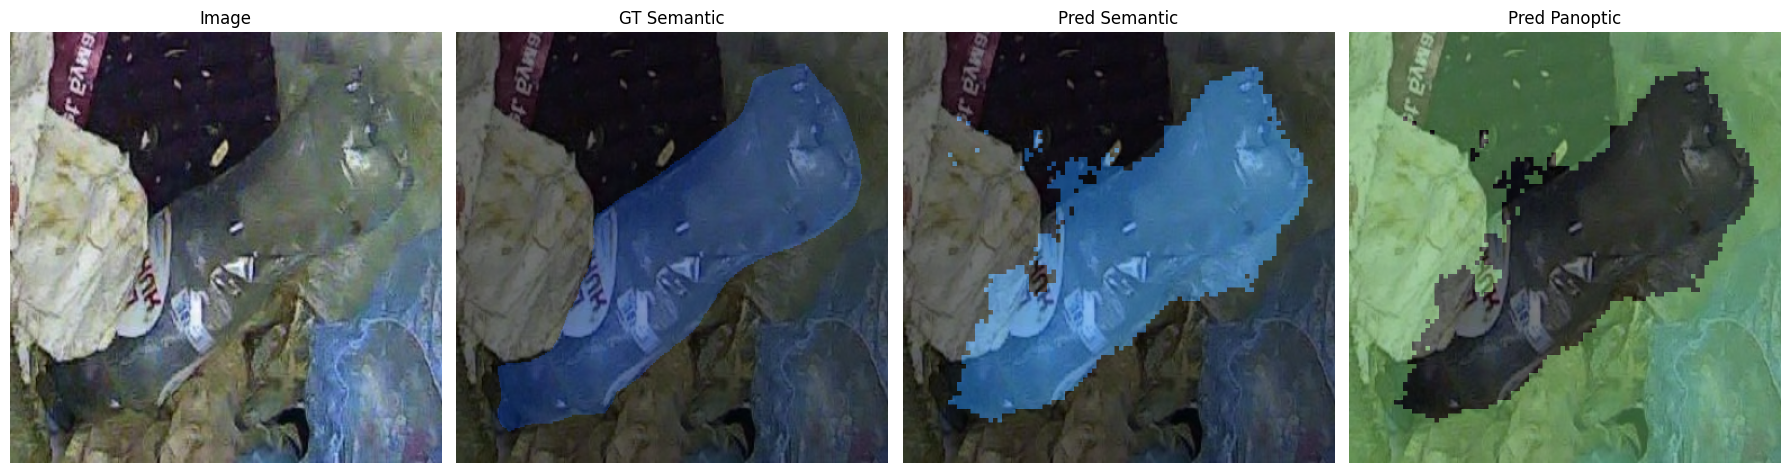

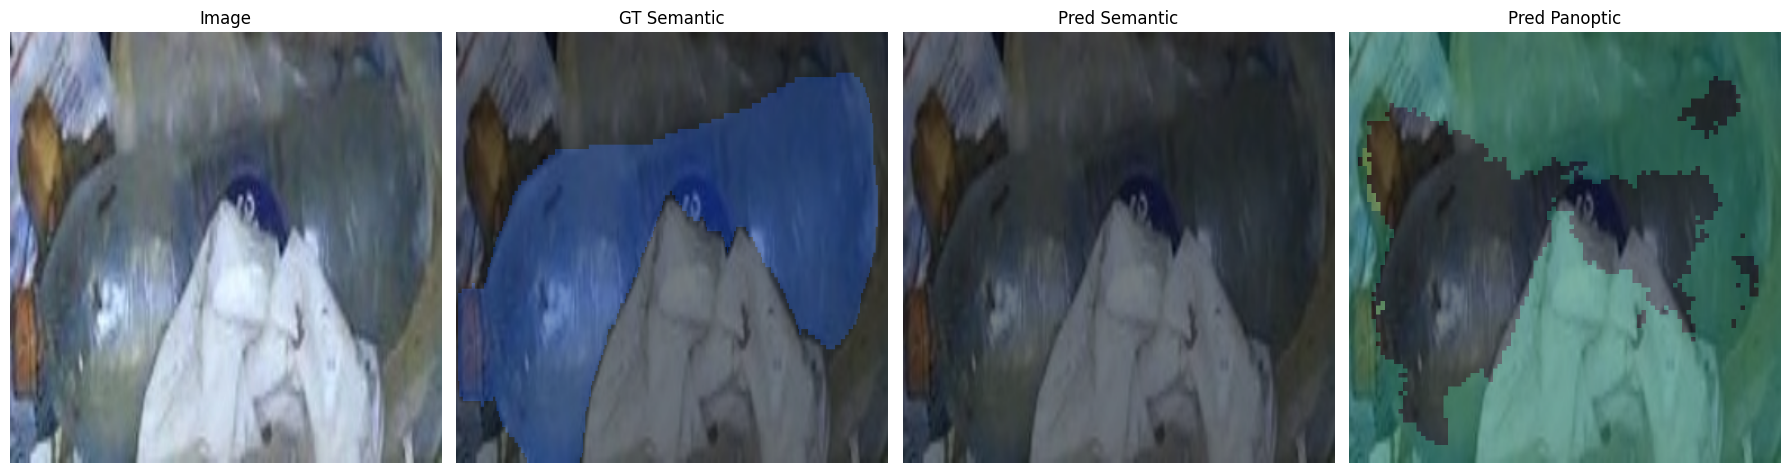

In [ ]:
# 15: Visualisation (semantic + panoptic)

def decode_mask_ids(mask_ids):
    h, w = mask_ids.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for (r, g, b), cid in rgb_to_id.items():
        rgb[mask_ids == cid] = (r, g, b)
    return rgb

def overlay_mask(image, mask_rgb, alpha=0.5):
    return (alpha * mask_rgb + (1 - alpha) * image).astype(np.uint8)


model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        class_logits, pred_masks = model(imgs)

        sem_pred, _ = semantic_from_queries(class_logits, pred_masks, NUM_CLASSES)
        sem_pred_up = F.interpolate(
            sem_pred.unsqueeze(1).float(),
            size=masks.shape[1:],
            mode="nearest",
        ).squeeze(1).long()

        pan_pred_list, _ = panoptic_from_queries(class_logits, pred_masks)

        imgs_np  = imgs.cpu().permute(0, 2, 3, 1).numpy()
        masks_np = masks.cpu().numpy()
        sem_pred_np = sem_pred_up.cpu().numpy()

        for b in range(min(4, imgs_np.shape[0])):
            img_vis = (imgs_np[b] * np.array([0.229, 0.224, 0.225]) +
                       np.array([0.485, 0.456, 0.406]))
            img_vis = (np.clip(img_vis, 0, 1) * 255).astype(np.uint8)

            gt_rgb   = decode_mask_ids(masks_np[b])
            pred_rgb = decode_mask_ids(sem_pred_np[b])

            pan_pred = pan_pred_list[b]
            pan_pred_up = F.interpolate(
                pan_pred.unsqueeze(0).unsqueeze(0).float(),
                size=masks.shape[1:],
                mode="nearest",
            ).squeeze().cpu().numpy().astype(np.int32)

            pan_rgb = np.zeros_like(gt_rgb)
            rng = np.random.RandomState(42)
            colors = {}
            for inst_id in np.unique(pan_pred_up):
                if inst_id == 0:
                    continue
                colors[inst_id] = rng.randint(0, 255, size=3)
                pan_rgb[pan_pred_up == inst_id] = colors[inst_id]

            overlay_gt   = overlay_mask(img_vis, gt_rgb)
            overlay_sem  = overlay_mask(img_vis, pred_rgb)
            overlay_pan  = overlay_mask(img_vis, pan_rgb)

            fig, axs = plt.subplots(1, 4, figsize=(18, 5))
            axs[0].imshow(img_vis)
            axs[0].set_title("Image")
            axs[0].axis("off")

            axs[1].imshow(overlay_gt)
            axs[1].set_title("GT Semantic")
            axs[1].axis("off")

            axs[2].imshow(overlay_sem)
            axs[2].set_title("Pred Semantic")
            axs[2].axis("off")

            axs[3].imshow(overlay_pan)
            axs[3].set_title("Pred Panoptic")
            axs[3].axis("off")

            plt.tight_layout()
            plt.show()

        break